Local results:


,size,layout,listing_time_s,file_count,total_size_gb,selective_time_s,selective_rows,broad_time_s,broad_rows
0,S,flat,0.000142,1,0.096494,0.269470,96632,0.079408,5000000
1,S,by_date,0.003982,31,0.106110,0.077585,96632,0.435388,5000000
2,S,by_region,0.000525,5,0.102931,0.085449,96632,0.218205,5000000
3,M,flat,0.000321,1,0.482488,2.206686,483150,0.653403,25000000
4,M,by_date,0.014599,32,0.530543,0.705714,483150,7.647252,25000000


S3 results:


,size,layout,s3_prefix,s3_listing_time_s,object_count,total_size_gb
0,S,flat,curated/ubereats/S/flat/,0.119467,1,0.096494
1,S,by_date,curated/ubereats/S/by_date/,0.055578,31,0.106110
2,S,by_region,curated/ubereats/S/by_region/,0.013098,5,0.102931
3,M,flat,curated/ubereats/M/flat/,0.007169,1,0.482488
4,M,by_date,curated/ubereats/M/by_date/,0.043934,32,0.530543


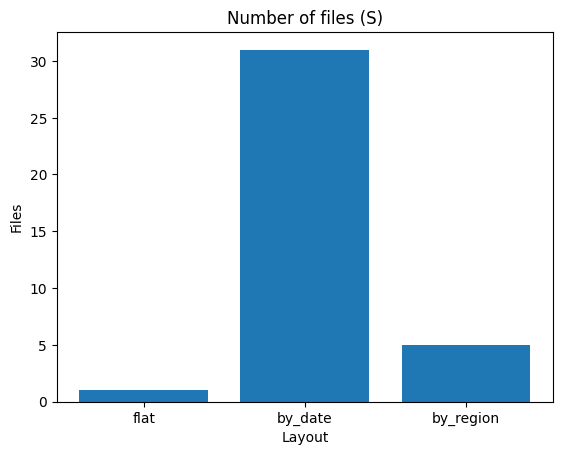

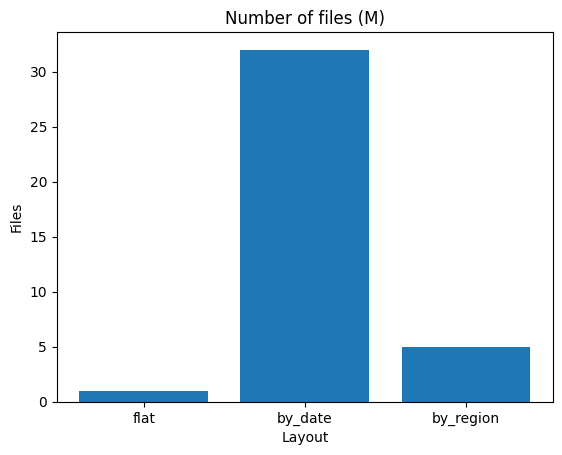

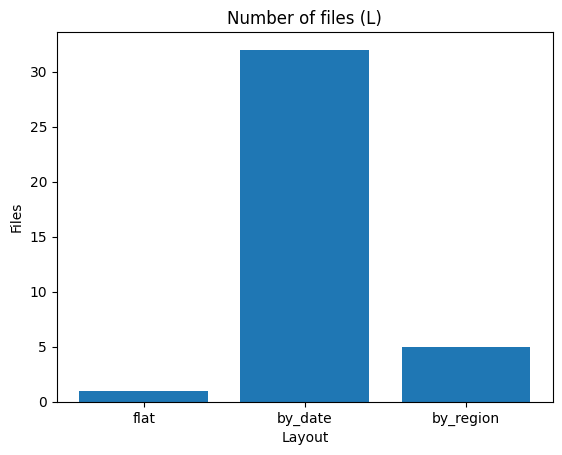

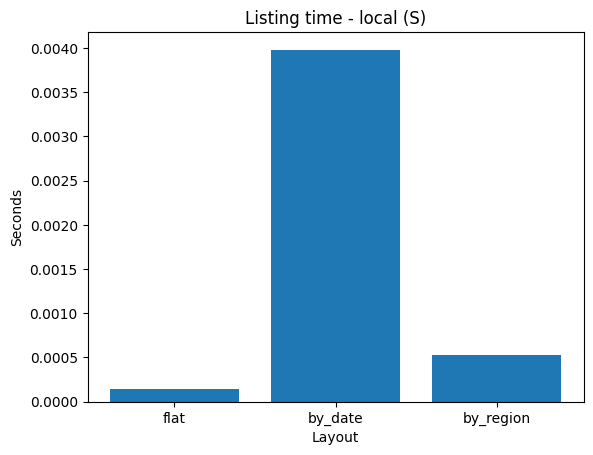

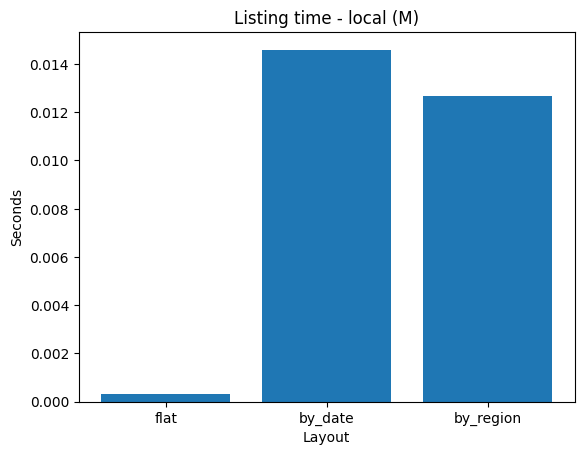

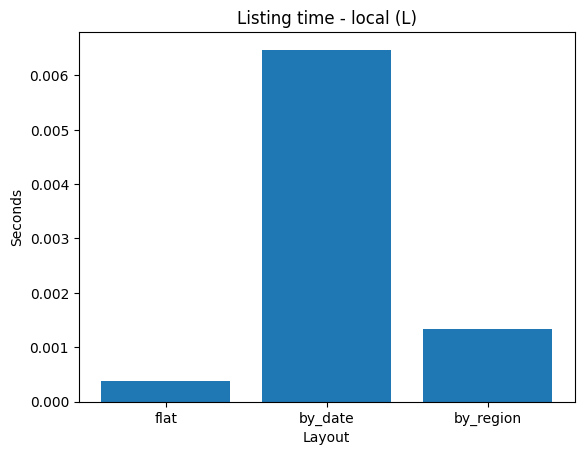

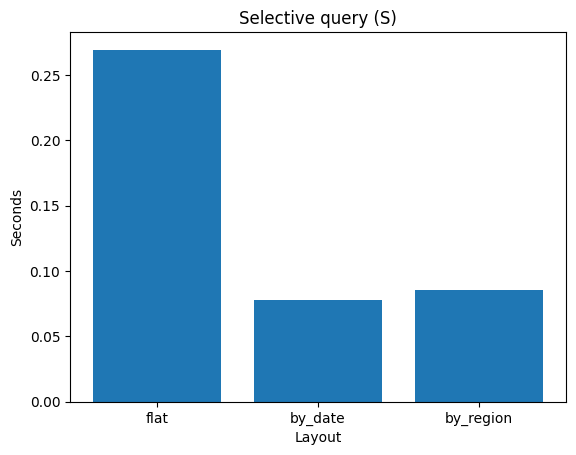

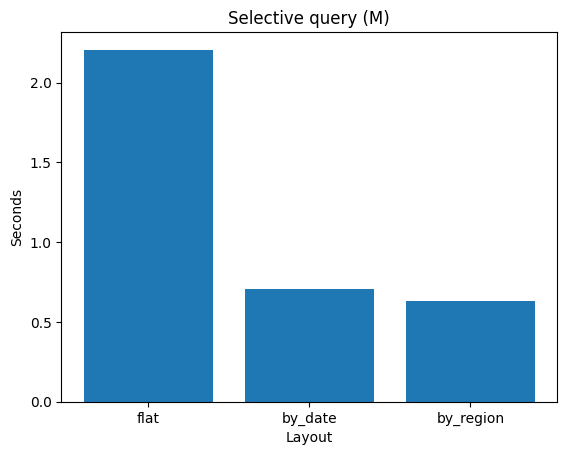

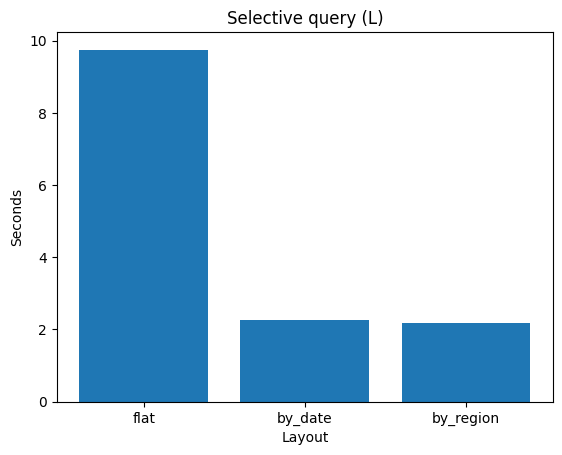

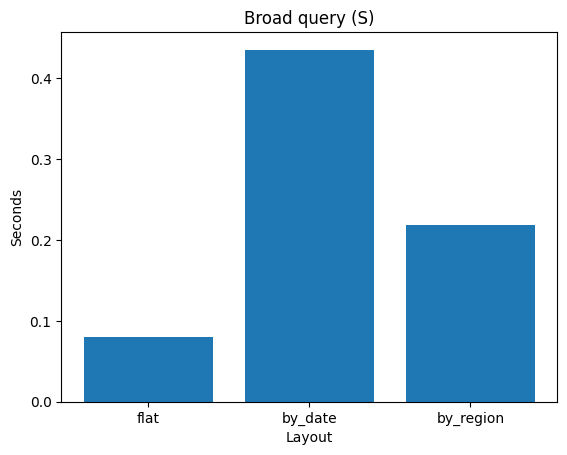

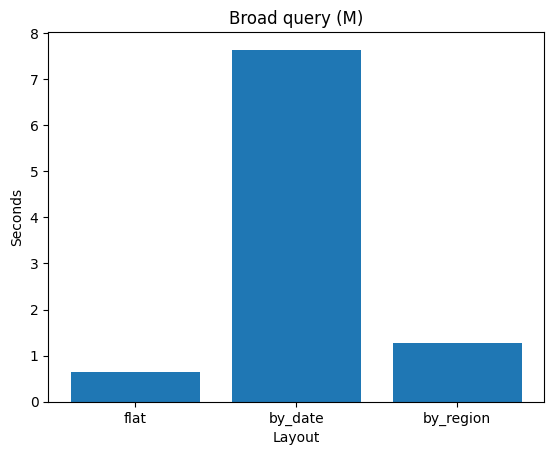

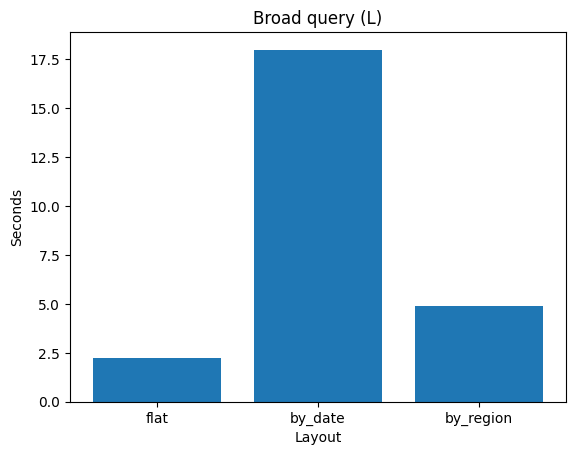

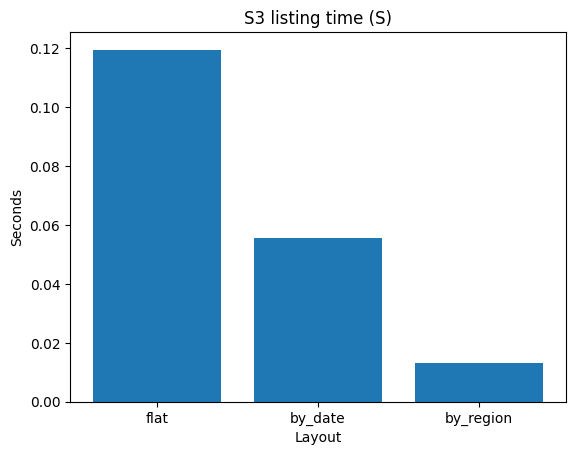

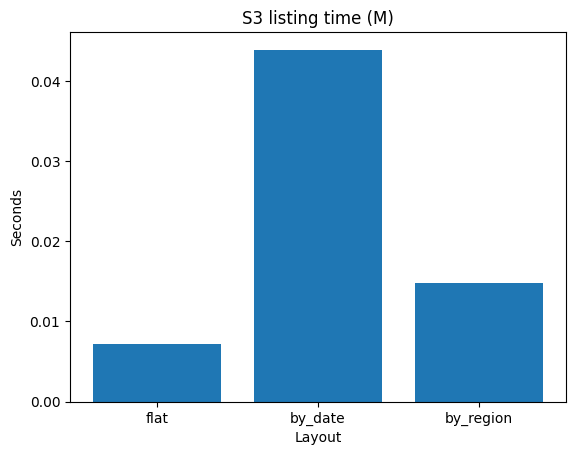

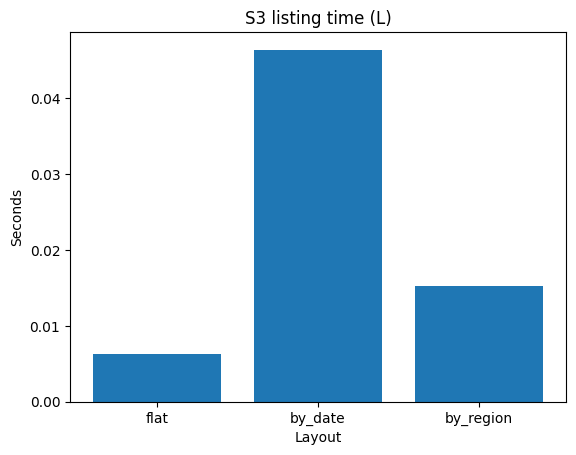


=== ANALYSIS SUMMARY ===

1. Partitioned layouts create more files than flat layout.
2. More files increase listing time, especially in S3.
3. Selective queries are faster with partitioning (especially by_region).
4. Broad queries show smaller differences between layouts.
5. S3 amplifies the cost of many small files (object overhead).

=== Combined comparison (local vs S3 listing) ===



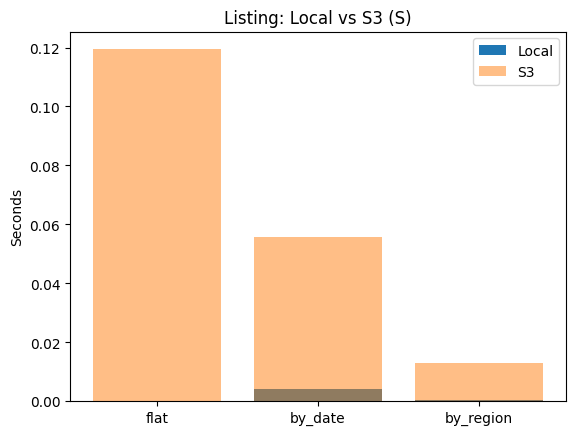

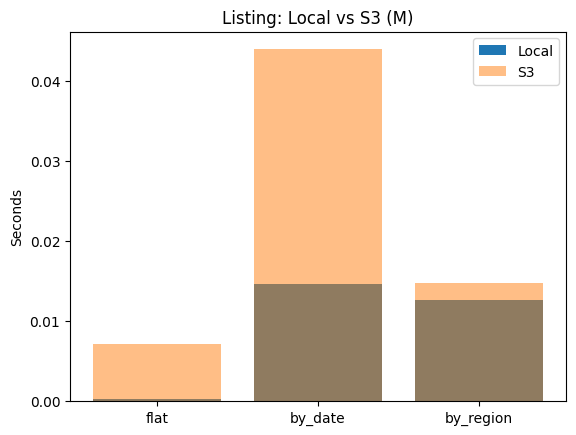

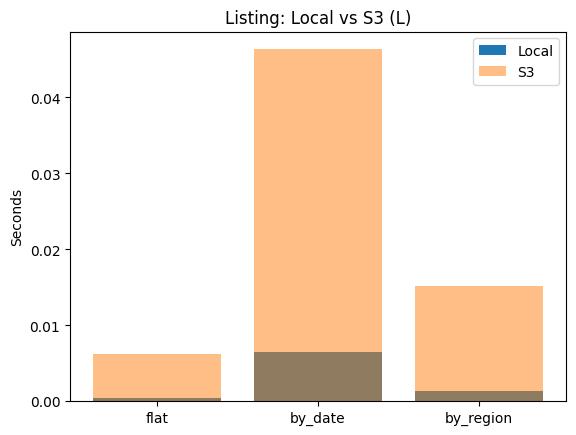

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

# ===== LOAD DATA =====
df_local = pd.read_csv("results.csv")
df_s3 = pd.read_csv("results_s3.csv")

print("Local results:")
display(df_local.head())

print("S3 results:")
display(df_s3.head())


# ===== FILE COUNT =====
for size in ["S", "M", "L"]:
    subset = df_local[df_local["size"] == size]

    plt.figure()
    plt.bar(subset["layout"], subset["file_count"])
    plt.title(f"Number of files ({size})")
    plt.xlabel("Layout")
    plt.ylabel("Files")
    plt.show()


# ===== LISTING TIME (LOCAL) =====
for size in ["S", "M", "L"]:
    subset = df_local[df_local["size"] == size]

    plt.figure()
    plt.bar(subset["layout"], subset["listing_time_s"])
    plt.title(f"Listing time - local ({size})")
    plt.xlabel("Layout")
    plt.ylabel("Seconds")
    plt.show()


# ===== SELECTIVE QUERY =====
for size in ["S", "M", "L"]:
    subset = df_local[df_local["size"] == size]

    plt.figure()
    plt.bar(subset["layout"], subset["selective_time_s"])
    plt.title(f"Selective query ({size})")
    plt.xlabel("Layout")
    plt.ylabel("Seconds")
    plt.show()


# ===== BROAD QUERY =====
for size in ["S", "M", "L"]:
    subset = df_local[df_local["size"] == size]

    plt.figure()
    plt.bar(subset["layout"], subset["broad_time_s"])
    plt.title(f"Broad query ({size})")
    plt.xlabel("Layout")
    plt.ylabel("Seconds")
    plt.show()


# ===== S3 LISTING =====
for size in ["S", "M", "L"]:
    subset = df_s3[df_s3["size"] == size]

    plt.figure()
    plt.bar(subset["layout"], subset["s3_listing_time_s"])
    plt.title(f"S3 listing time ({size})")
    plt.xlabel("Layout")
    plt.ylabel("Seconds")
    plt.show()


# ===== BASIC TEXT OUTPUT =====
print("\n=== ANALYSIS SUMMARY ===\n")

print("1. Partitioned layouts create more files than flat layout.")
print("2. More files increase listing time, especially in S3.")
print("3. Selective queries are faster with partitioning (especially by_region).")
print("4. Broad queries show smaller differences between layouts.")
print("5. S3 amplifies the cost of many small files (object overhead).")


# ===== OPTIONAL: COMBINED VIEW =====
print("\n=== Combined comparison (local vs S3 listing) ===\n")

merged = df_local.merge(
    df_s3,
    on=["size", "layout"],
    suffixes=("_local", "_s3")
)

for size in ["S", "M", "L"]:
    subset = merged[merged["size"] == size]

    plt.figure()
    plt.bar(subset["layout"], subset["listing_time_s"], label="Local")
    plt.bar(subset["layout"], subset["s3_listing_time_s"], alpha=0.5, label="S3")
    plt.title(f"Listing: Local vs S3 ({size})")
    plt.ylabel("Seconds")
    plt.legend()
    plt.show()